**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4033 - Visión computacional para imágenes y video**

Tecnológico de Monterrey

Prof Gilberto Ochoa Ruiz

**Semana 9**
Otsu Thresholding

---

**Equipo 23**

|                 NOMBRE              | MATRÍCULA |
|-------------------------------------|-----------|
| Luis Fernando Caporal Montes de Oca | A01795898 |  
| David Alexis García Espinosa        | A01795178 |
| Jorge Santana Mendoza               | A01376306 |
| José Manuel Romo Peredo             | A01065270 |
| Luis Daniel Ortega Muñoz            | A01795197 |
             

# 6. Otsu Thresholding

## Table of Contents
1. [Libraries](#libraries)
2. [Single Thresholding](#single)
3. [Multi Thresholding](#multi)

Thresholding is used to create a binary image from a grayscale image

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import matplotlib.pyplot as plt
from skimage import data
from skimage.filters import threshold_otsu
from skimage.filters import threshold_multiotsu
import numpy as np

## Single Thresholding <a class="anchor" id="single" ></a>

We illustrate how to apply one of these thresholding algorithms.
Otsu's method [2]_ calculates an "optimal" threshold (marked by a red line in the
histogram below) by maximizing the variance between two classes of pixels,
which are separated by the threshold. Equivalently, this threshold minimizes
the intra-class variance.

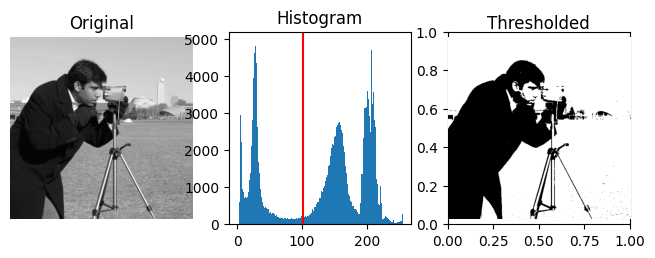

In [2]:
image = data.camera()
thresh = threshold_otsu(image)
binary = image > thresh

fig, axes = plt.subplots(ncols=3, figsize=(8, 2.5))
ax = axes.ravel()
ax[0] = plt.subplot(1, 3, 1)
ax[1] = plt.subplot(1, 3, 2)
ax[2] = plt.subplot(1, 3, 3, sharex=ax[0], sharey=ax[0])

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].hist(image.ravel(), bins=256)
ax[1].set_title('Histogram')
ax[1].axvline(thresh, color='r')

ax[2].imshow(binary, cmap=plt.cm.gray)
ax[2].set_title('Thresholded')
ax[2].axis('off')

plt.show()

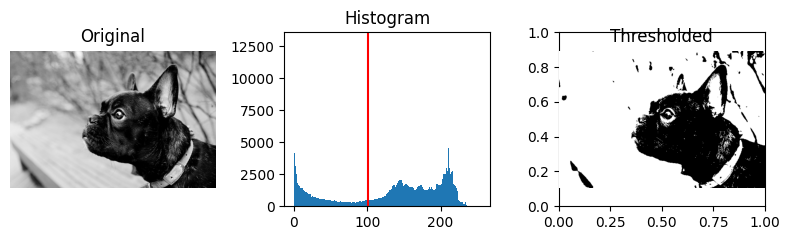

In [3]:
import cv2

# Reading the image
image = cv2.imread('data/imagen4.jpg', cv2.IMREAD_GRAYSCALE)

# Apply Otsu thresholding
thresh = threshold_otsu(image)
binary = image > thresh

# Plotting the results
fig, axes = plt.subplots(ncols=3, figsize=(8, 2.5))
ax = axes.ravel()

ax[0] = plt.subplot(1, 3, 1)
ax[1] = plt.subplot(1, 3, 2)
ax[2] = plt.subplot(1, 3, 3, sharex=ax[0], sharey=ax[0])

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].hist(image.ravel(), bins=256)
ax[1].set_title('Histogram')
ax[1].axvline(thresh, color='r')

ax[2].imshow(binary, cmap=plt.cm.gray)
ax[2].set_title('Thresholded')
ax[2].axis('off')

plt.tight_layout()
plt.show()

If you are not familiar with the details of the different algorithms and the
underlying assumptions, it is often difficult to know which algorithm will give
the best results. Therefore, Scikit-image includes a function to evaluate
thresholding algorithms provided by the library. At a glance, you can select
the best algorithm for your data without a deep understanding of their
mechanisms.




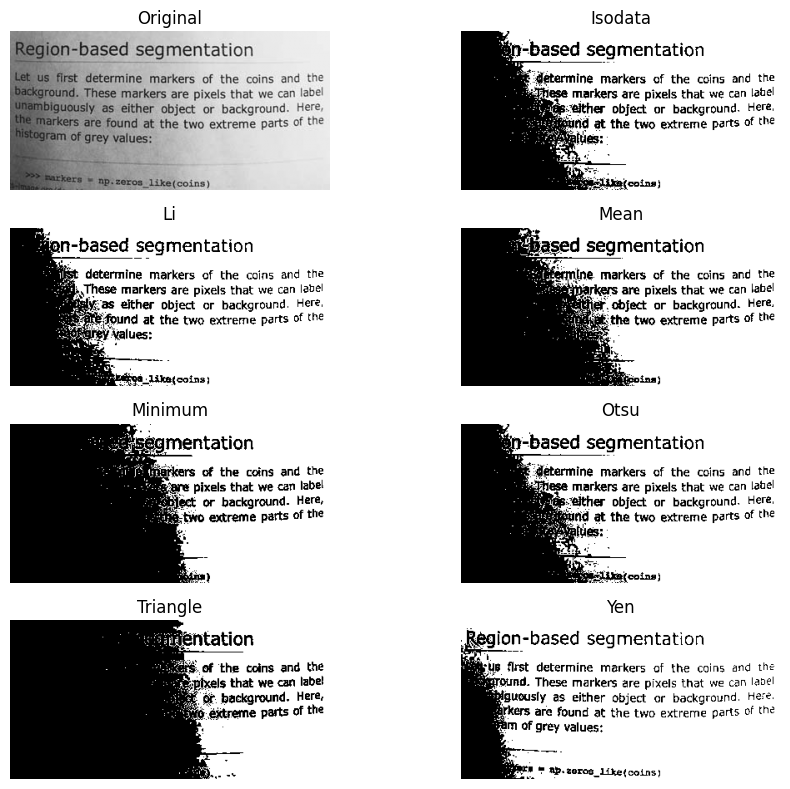

In [4]:
from skimage.filters import try_all_threshold

img = data.page()

fig, ax = try_all_threshold(img, figsize=(10, 8), verbose=False)
plt.show()

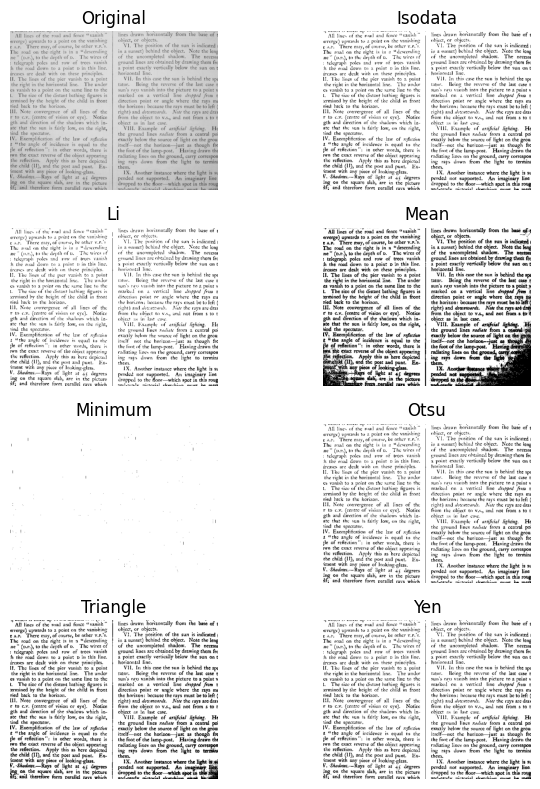

In [5]:
# Reading the image
image = cv2.imread('data/imagen6.jpg', cv2.IMREAD_GRAYSCALE)

# Applying try_all_threshold
fig, ax = try_all_threshold(image, figsize=(10, 8), verbose=False)

# Displaying the results
plt.tight_layout()
plt.show()

In [6]:
# TODO: Slide image for segmentation, alpha blerding

## Multi Thresholding <a class="anchor" id="multi" ></a>

The multi-Otsu threshold  is a thresholding algorithm that is used to separate
the pixels of an input image into several different classes, each one obtained
according to the intensity of the gray levels within the image.

Multi-Otsu calculates several thresholds, determined by the number of desired
classes. The default number of classes is 3: for obtaining three classes, the
algorithm returns two threshold values. They are represented by a red line in
the histogram below.

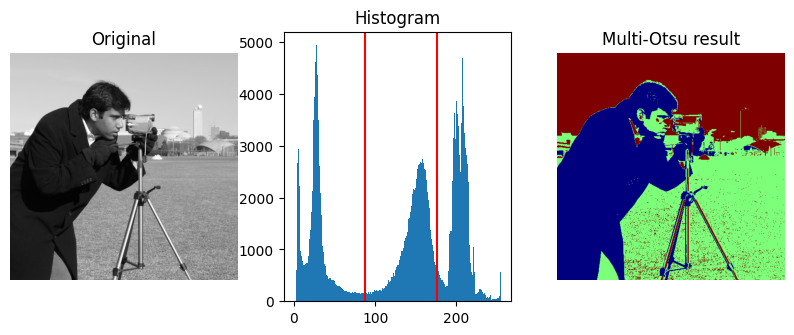

In [7]:
# The input image.
image = data.camera()

# Applying multi-Otsu threshold for the default value, generating
# three classes.
thresholds = threshold_multiotsu(image)

# Using the threshold values, we generate the three regions.
regions = np.digitize(image, bins=thresholds)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3.5))

# Plotting the original image.
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the two thresholds obtained from
# multi-Otsu.
ax[1].hist(image.ravel(), bins=255)
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')

# Plotting the Multi Otsu result.
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multi-Otsu result')
ax[2].axis('off')

plt.subplots_adjust()

plt.show()

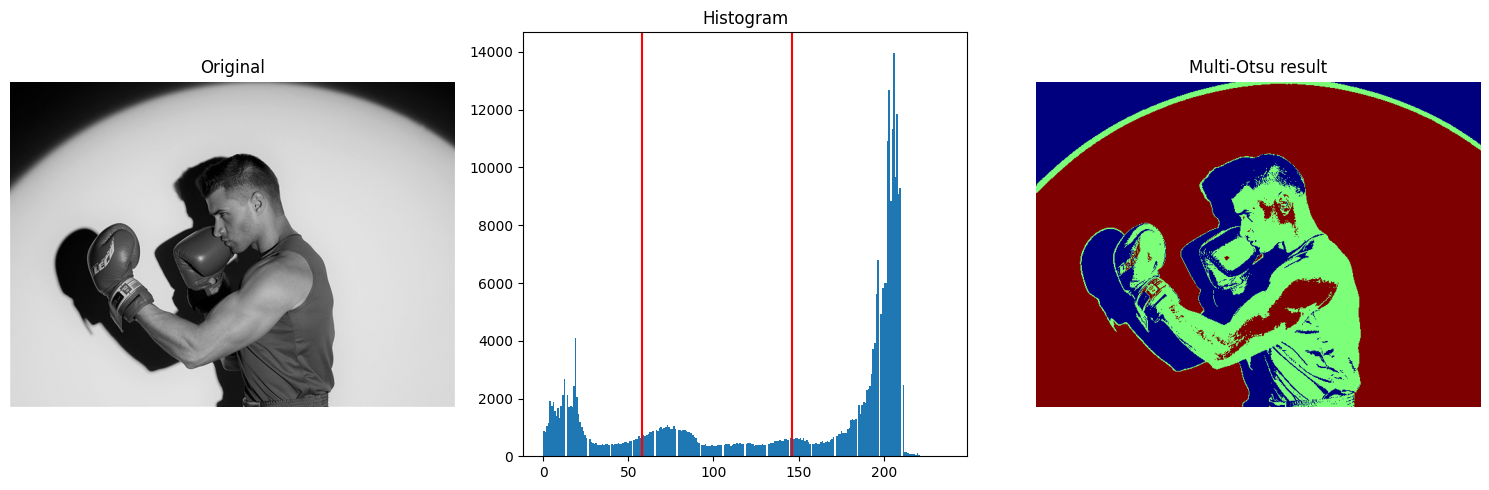

In [8]:
# Reading the image
image = cv2.imread('data/imagen2.jpg', cv2.IMREAD_GRAYSCALE)

# Applying multi-Otsu threshold for the default value, generating three classes
thresholds = threshold_multiotsu(image)

# Using the threshold values, we generate the three regions
regions = np.digitize(image, bins=thresholds)

# Plotting the results
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Plotting the original image
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the two thresholds obtained from multi-Otsu
ax[1].hist(image.ravel(), bins=255)
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')

# Plotting the Multi-Otsu result
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multi-Otsu result')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Adaptive Thresholding <a class="anchor" id="adap" ></a>

Para aplicar el método de Otsu en ventanas de diferentes tamaños, podemos utilizar una técnica llamada "Adaptive Thresholding" o umbralización adaptativa. Esta técnica divide la imagen en bloques más pequeños y aplica un umbral en cada uno, lo que puede mejorar los resultados en imágenes con variaciones de iluminación.

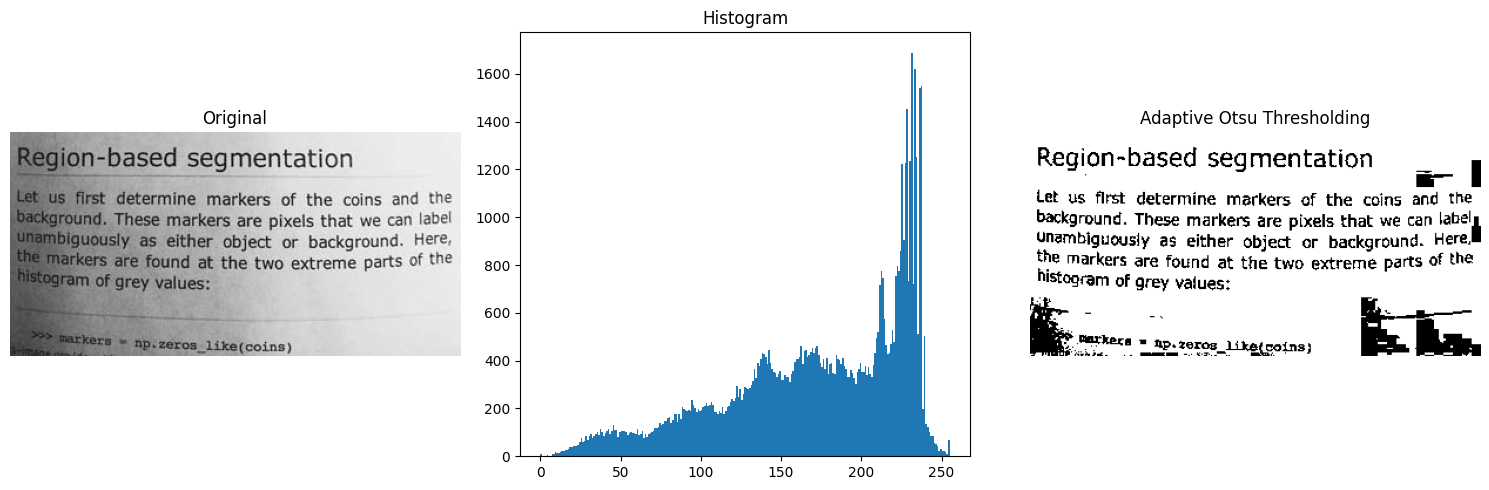

In [10]:
# Leer la imagen
image = data.page()

# Aplicar umbralización adaptativa con Otsu
window_size = 47  # Tamaño de la ventana (debe ser impar)
binary_adaptive = np.zeros_like(image)

for i in range(0, image.shape[0], window_size):
    for j in range(0, image.shape[1], window_size):
        # Definir las coordenadas de la ventana
        x_start = j
        x_end = min(j + window_size, image.shape[1])
        y_start = i
        y_end = min(i + window_size, image.shape[0])

        # Extraer el bloque de la imagen
        block = image[y_start:y_end, x_start:x_end]

        # Aplicar Otsu al bloque
        if block.size > 0:
            thresh = threshold_otsu(block)
            binary_adaptive[y_start:y_end, x_start:x_end] = block > thresh

# Plotting the results
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Imagen original
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Histograma de la imagen
ax[1].hist(image.ravel(), bins=255)
ax[1].set_title('Histogram')

# Imagen umbralizada adaptativamente
ax[2].imshow(binary_adaptive, cmap='gray')
ax[2].set_title('Adaptive Otsu Thresholding')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Comparando thresholding con diferentes tipos de imágenes

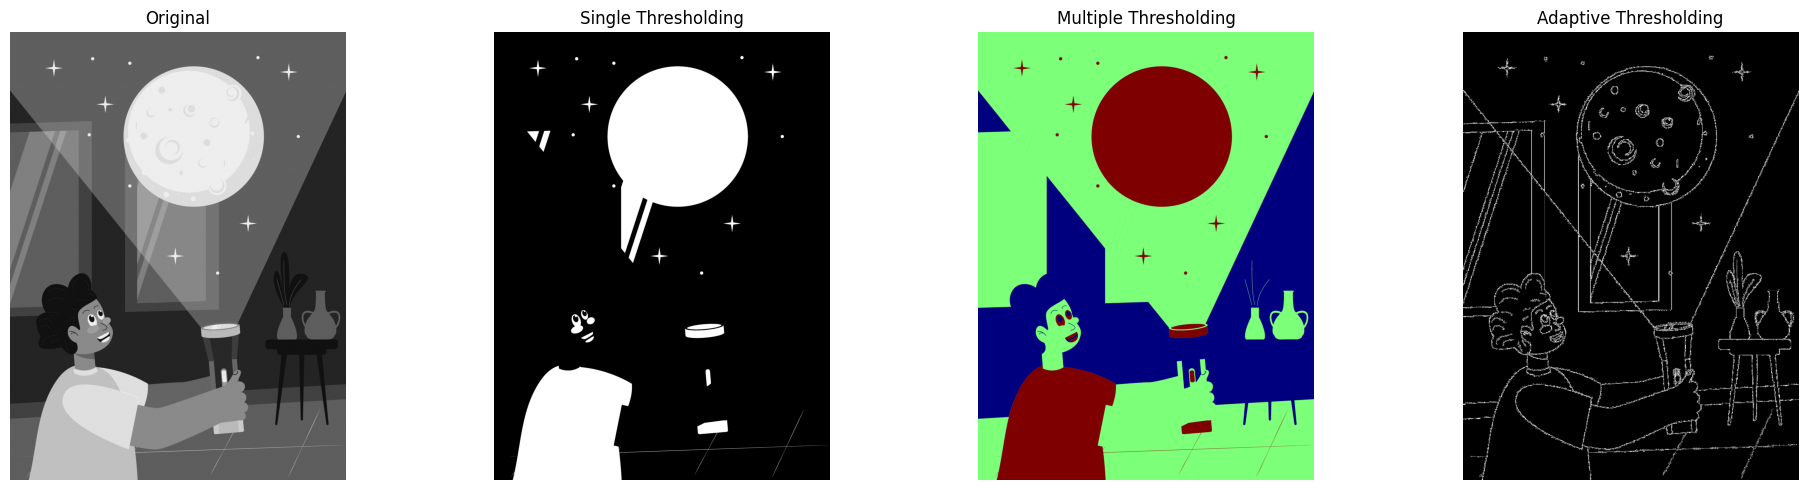

In [11]:
# Visualización comparativa
image = cv2.imread('data/imagen11.jpg', cv2.IMREAD_GRAYSCALE)

# Umbralización simple (Single Thresholding)
thresh = threshold_otsu(image)
binary = image > thresh

# Umbralización múltiple (Multiple Thresholding)
thresholds = threshold_multiotsu(image)
regions = np.digitize(image, bins=thresholds)

# Umbralización adaptativa (Adaptive Thresholding)
window_size =7
binary_adaptive = np.zeros_like(image)

for i in range(0, image.shape[0], window_size):
    for j in range(0, image.shape[1], window_size):
        block = image[i:i+window_size, j:j+window_size]
        if block.size > 0:
            thresh = threshold_otsu(block)
            binary_adaptive[i:i+window_size, j:j+window_size] = block > thresh

# Visualización comparativa
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

# Imagen original
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Umbralización simple
ax[1].imshow(binary, cmap='gray')
ax[1].set_title('Single Thresholding')
ax[1].axis('off')

# Umbralización múltiple
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multiple Thresholding')
ax[2].axis('off')

# Umbralización adaptativa
ax[3].imshow(binary_adaptive, cmap='gray')
ax[3].set_title('Adaptive Thresholding')
ax[3].axis('off')

plt.tight_layout()
plt.show()

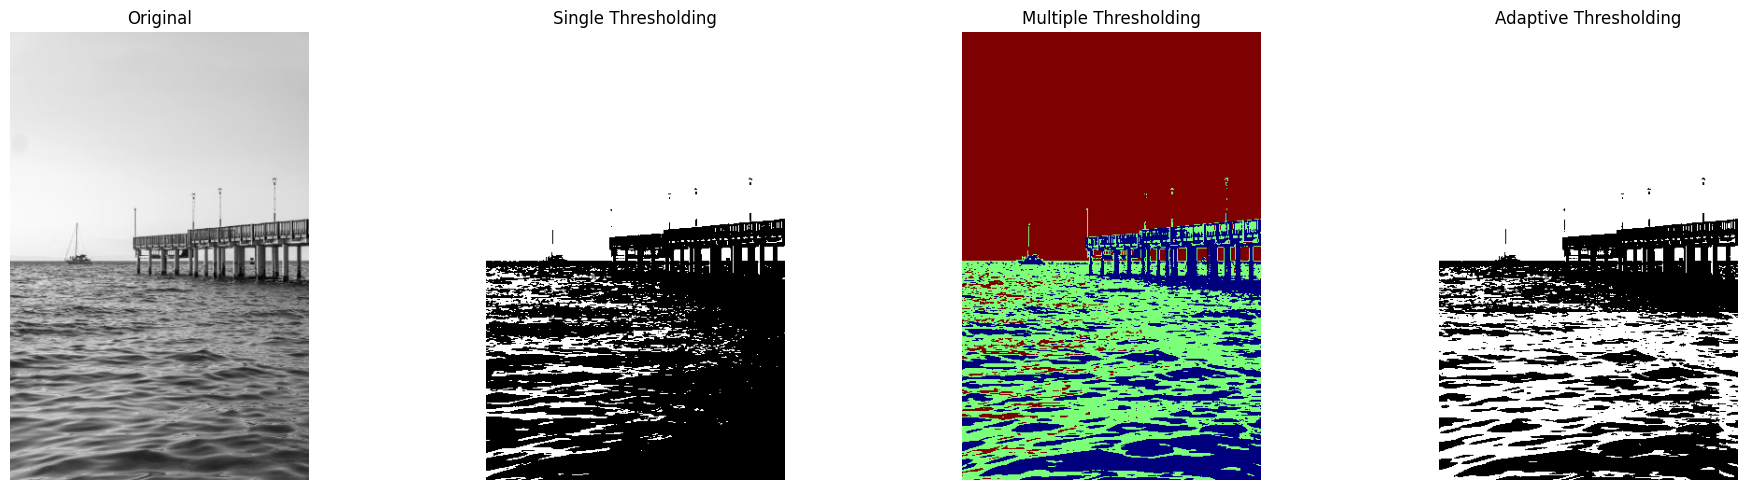

In [19]:
# Visualización comparativa
image = cv2.imread('data/imagen13.jpg', cv2.IMREAD_GRAYSCALE)

# Umbralización simple (Single Thresholding)
thresh = threshold_otsu(image)
binary = image > thresh

# Umbralización múltiple (Multiple Thresholding)
thresholds = threshold_multiotsu(image)
regions = np.digitize(image, bins=thresholds)

# Umbralización adaptativa (Adaptive Thresholding)
window_size =300
binary_adaptive = np.zeros_like(image)

for i in range(0, image.shape[0], window_size):
    for j in range(0, image.shape[1], window_size):
        block = image[i:i+window_size, j:j+window_size]
        if block.size > 0:
            thresh = threshold_otsu(block)
            binary_adaptive[i:i+window_size, j:j+window_size] = block > thresh

# Visualización comparativa
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

# Imagen original
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Umbralización simple
ax[1].imshow(binary, cmap='gray')
ax[1].set_title('Single Thresholding')
ax[1].axis('off')

# Umbralización múltiple
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multiple Thresholding')
ax[2].axis('off')

# Umbralización adaptativa
ax[3].imshow(binary_adaptive, cmap='gray')
ax[3].set_title('Adaptive Thresholding')
ax[3].axis('off')

plt.tight_layout()
plt.show()

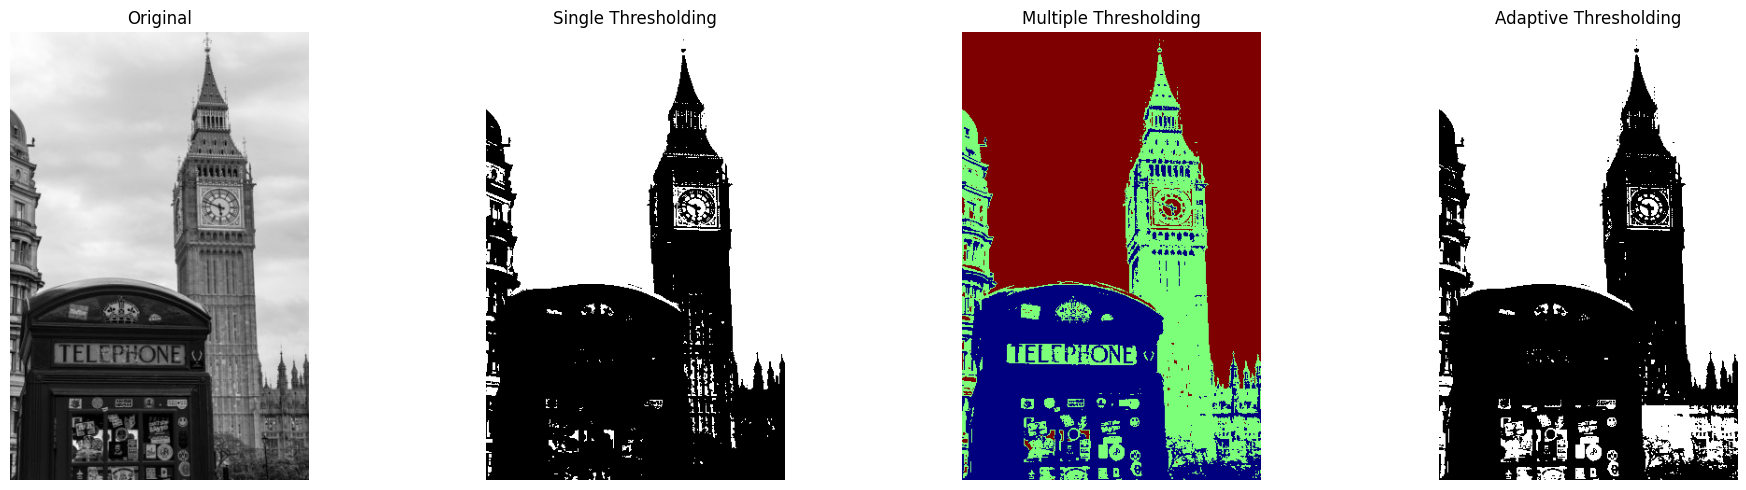

In [34]:
# Visualización comparativa
image = cv2.imread('data/imagen14.jpg', cv2.IMREAD_GRAYSCALE)

# Umbralización simple (Single Thresholding)
thresh = threshold_otsu(image)
binary = image > thresh

# Umbralización múltiple (Multiple Thresholding)
thresholds = threshold_multiotsu(image)
regions = np.digitize(image, bins=thresholds)

# Umbralización adaptativa (Adaptive Thresholding)
window_size =200
binary_adaptive = np.zeros_like(image)

for i in range(0, image.shape[0], window_size):
    for j in range(0, image.shape[1], window_size):
        block = image[i:i+window_size, j:j+window_size]
        if block.size > 0:
            thresh = threshold_otsu(block)
            binary_adaptive[i:i+window_size, j:j+window_size] = block > thresh

# Visualización comparativa
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

# Imagen original
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Umbralización simple
ax[1].imshow(binary, cmap='gray')
ax[1].set_title('Single Thresholding')
ax[1].axis('off')

# Umbralización múltiple
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multiple Thresholding')
ax[2].axis('off')

# Umbralización adaptativa
ax[3].imshow(binary_adaptive, cmap='gray')
ax[3].set_title('Adaptive Thresholding')
ax[3].axis('off')

plt.tight_layout()
plt.show()

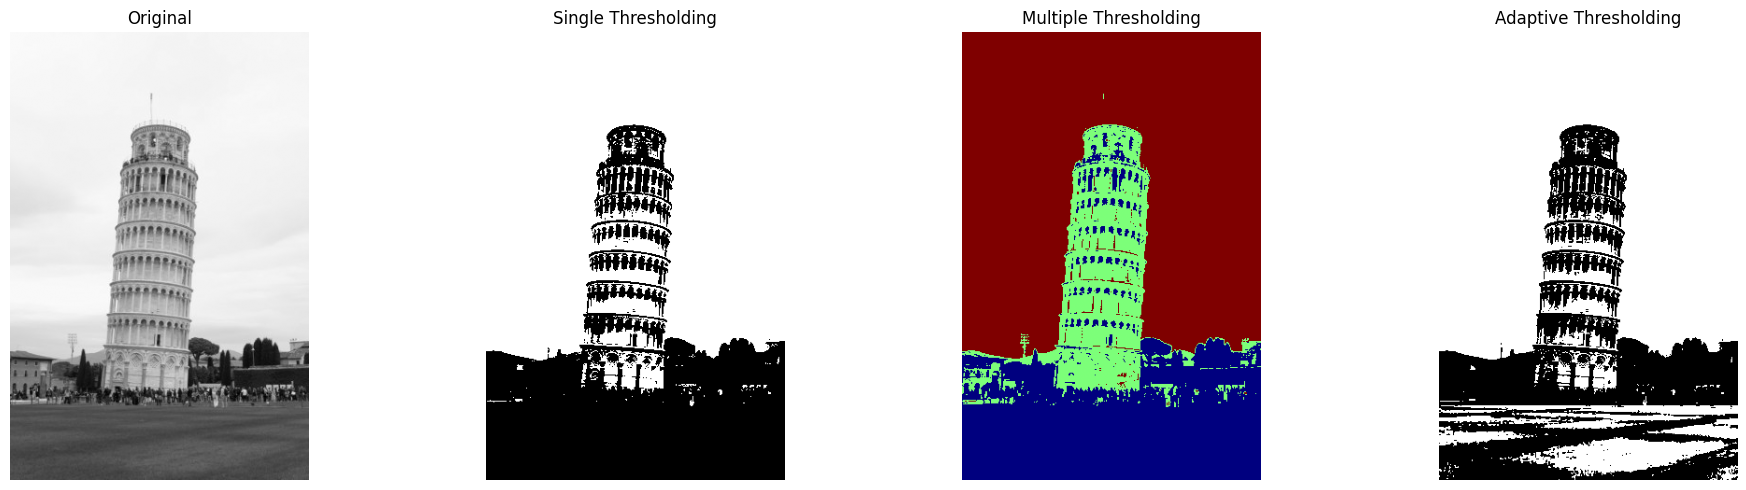

In [27]:
# Visualización comparativa
image = cv2.imread('data/imagen15.jpg', cv2.IMREAD_GRAYSCALE)

# Umbralización simple (Single Thresholding)
thresh = threshold_otsu(image)
binary = image > thresh

# Umbralización múltiple (Multiple Thresholding)
thresholds = threshold_multiotsu(image)
regions = np.digitize(image, bins=thresholds)

# Umbralización adaptativa (Adaptive Thresholding)
window_size =400
binary_adaptive = np.zeros_like(image)

for i in range(0, image.shape[0], window_size):
    for j in range(0, image.shape[1], window_size):
        block = image[i:i+window_size, j:j+window_size]
        if block.size > 0:
            thresh = threshold_otsu(block)
            binary_adaptive[i:i+window_size, j:j+window_size] = block > thresh

# Visualización comparativa
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

# Imagen original
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Umbralización simple
ax[1].imshow(binary, cmap='gray')
ax[1].set_title('Single Thresholding')
ax[1].axis('off')

# Umbralización múltiple
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multiple Thresholding')
ax[2].axis('off')

# Umbralización adaptativa
ax[3].imshow(binary_adaptive, cmap='gray')
ax[3].set_title('Adaptive Thresholding')
ax[3].axis('off')

plt.tight_layout()
plt.show()

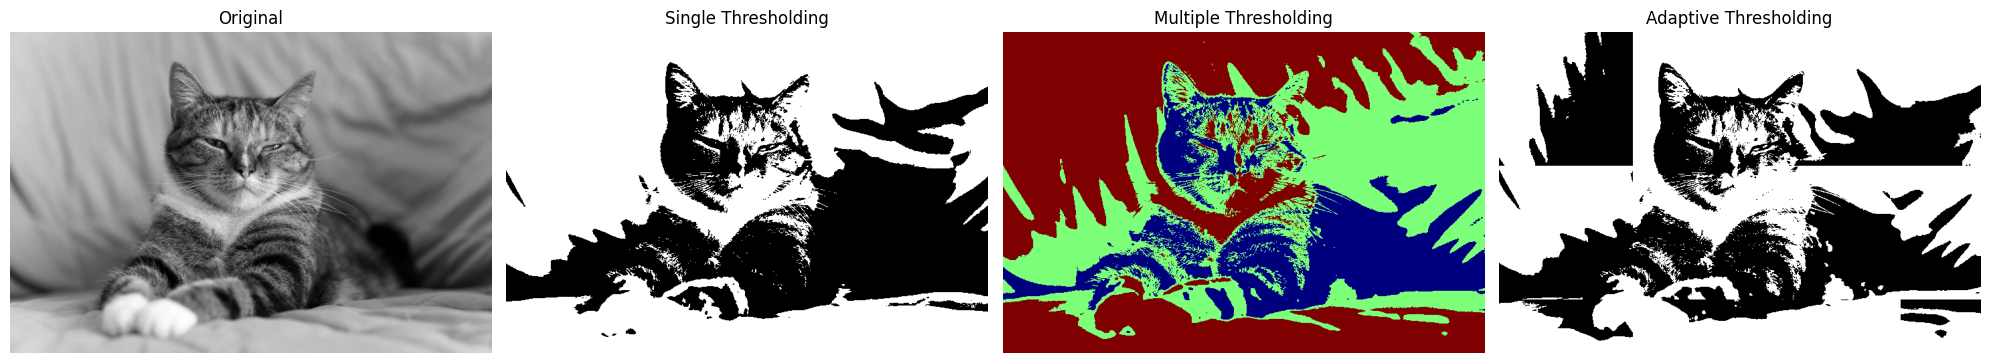

In [26]:
# Visualización comparativa
image = cv2.imread('data/imagen16.jpg', cv2.IMREAD_GRAYSCALE)

# Umbralización simple (Single Thresholding)
thresh = threshold_otsu(image)
binary = image > thresh

# Umbralización múltiple (Multiple Thresholding)
thresholds = threshold_multiotsu(image)
regions = np.digitize(image, bins=thresholds)

# Umbralización adaptativa (Adaptive Thresholding)
window_size =200
binary_adaptive = np.zeros_like(image)

for i in range(0, image.shape[0], window_size):
    for j in range(0, image.shape[1], window_size):
        block = image[i:i+window_size, j:j+window_size]
        if block.size > 0:
            thresh = threshold_otsu(block)
            binary_adaptive[i:i+window_size, j:j+window_size] = block > thresh

# Visualización comparativa
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

# Imagen original
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Umbralización simple
ax[1].imshow(binary, cmap='gray')
ax[1].set_title('Single Thresholding')
ax[1].axis('off')

# Umbralización múltiple
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multiple Thresholding')
ax[2].axis('off')

# Umbralización adaptativa
ax[3].imshow(binary_adaptive, cmap='gray')
ax[3].set_title('Adaptive Thresholding')
ax[3].axis('off')

plt.tight_layout()
plt.show()

## Análisis <a class="anchor" id="adap" ></a>

1. **Single Thresholding (Umbralización Simple)**
* Descripción: Este método utiliza un único valor de umbral para segmentar la imagen en dos regiones: una por encima del umbral y otra por debajo. El método de Otsu es un ejemplo clásico de umbralización simple.

* Ventajas:

  * Fácil de implementar.

  * Adecuado para imágenes con buena separación de fondo y objeto.

* Desventajas:

  * Sensible a variaciones de iluminación.

  * No funciona bien con imágenes complejas o con múltiples objetos.

2. **Multiple Thresholding (Umbralización Múltiple)**
* Descripción: Este método utiliza múltiples valores de umbral para segmentar la imagen en más de dos regiones. El umbral múltiple de Otsu genera varias clases utilizando diferentes umbrales.

* Ventajas:

  * Permite segmentar imágenes en más de dos regiones.

  * Mejor en imágenes con múltiples niveles de intensidad.

* Desventajas:

  * Más complejo de implementar.

  * Puede no ser efectivo con variaciones de iluminación.

3. **Adaptive Thresholding (Umbralización Adaptativa)**
* Descripción: Este método aplica umbrales locales a diferentes bloques de la imagen, lo que permite adaptarse a variaciones de iluminación. El umbral adaptativo puede ser una versión local del método de Otsu.

* Ventajas:

  * Funciona bien con imágenes con variaciones de iluminación.

  * Mejora los resultados en imágenes con detalles finos o gradientes.

* Desventajas:

  * Más tiempo de cálculo debido a la aplicación de umbrales en bloques.

  * Requiere la elección adecuada del tamaño de la ventana.